In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv("./input/train.csv")
test = pd.read_csv("./input/test.csv")


In [6]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


In [7]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
saleprice = train["SalePrice"]

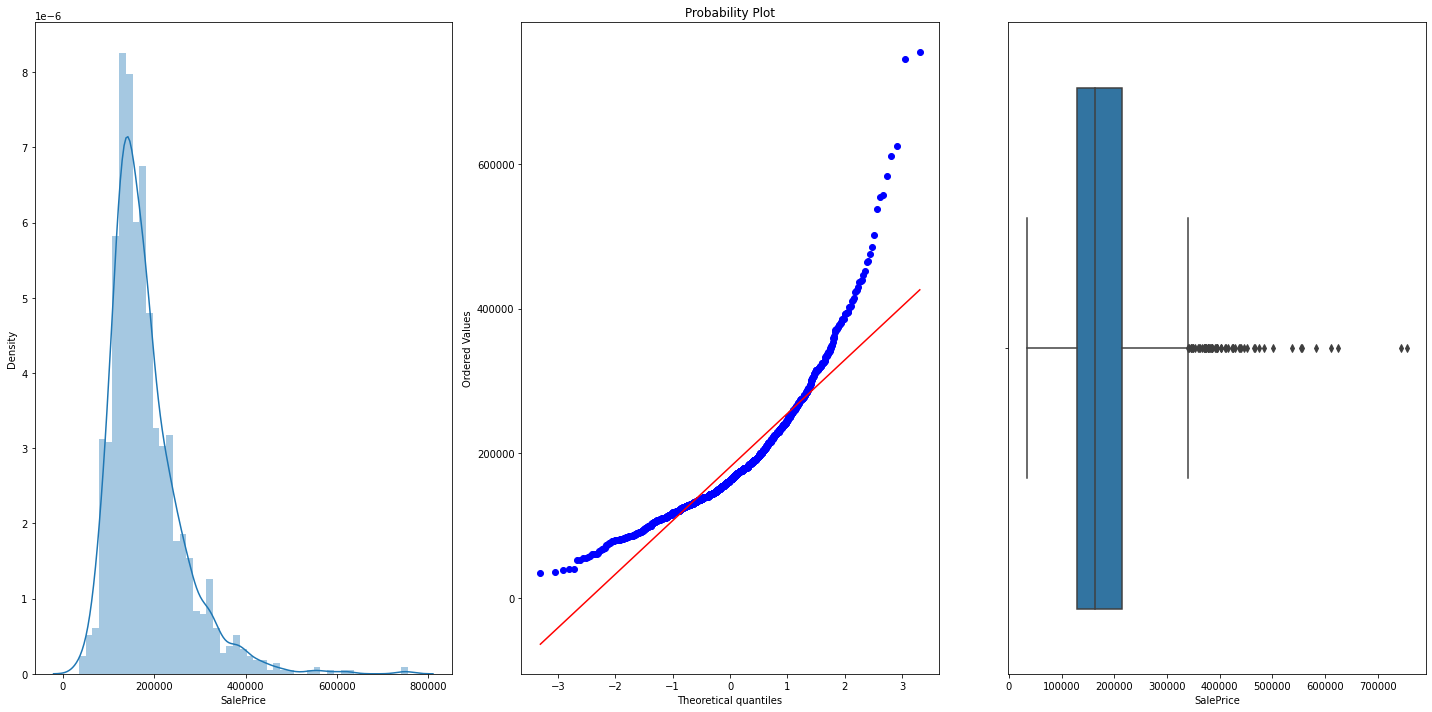

In [13]:
plt.figure(figsize=(20,10))

plt.subplot(131)
sns.distplot(saleprice)

plt.subplot(132)
stats.probplot(saleprice, plot=plt)

plt.subplot(133)
sns.boxplot(saleprice)
plt.tight_layout()
plt.show()

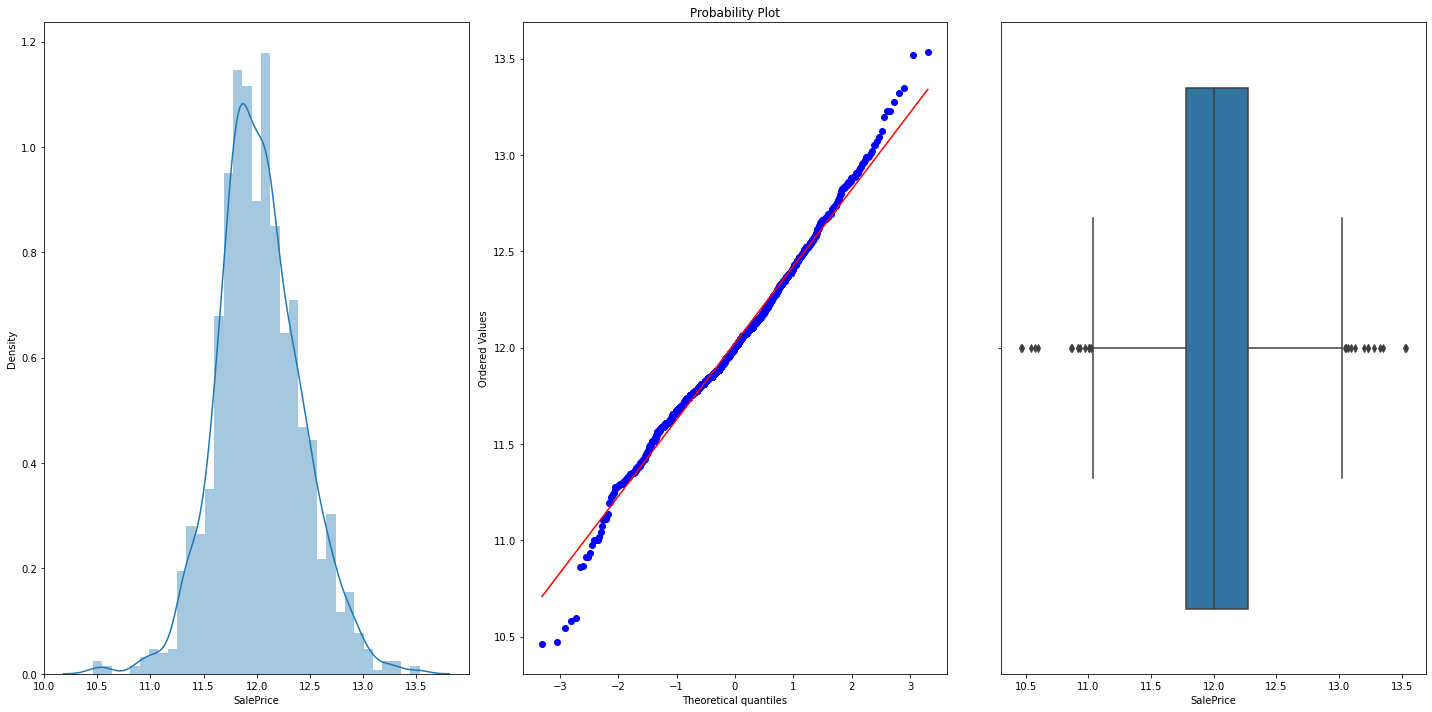

In [14]:
plt.figure(figsize=(20,10))
normalized = np.log1p(saleprice)
plt.subplot(131)
sns.distplot(normalized)

plt.subplot(132)
stats.probplot(normalized, plot=plt)

plt.subplot(133)
sns.boxplot(normalized)
plt.tight_layout()
plt.show()

In [19]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [22]:
train['MSSubClass'].dtype

dtype('int64')

In [23]:
number = []
category = []

for c in train.columns:
    if train[c].dtype == 'object':
        category.append(c)
    else:
        number.append(c)

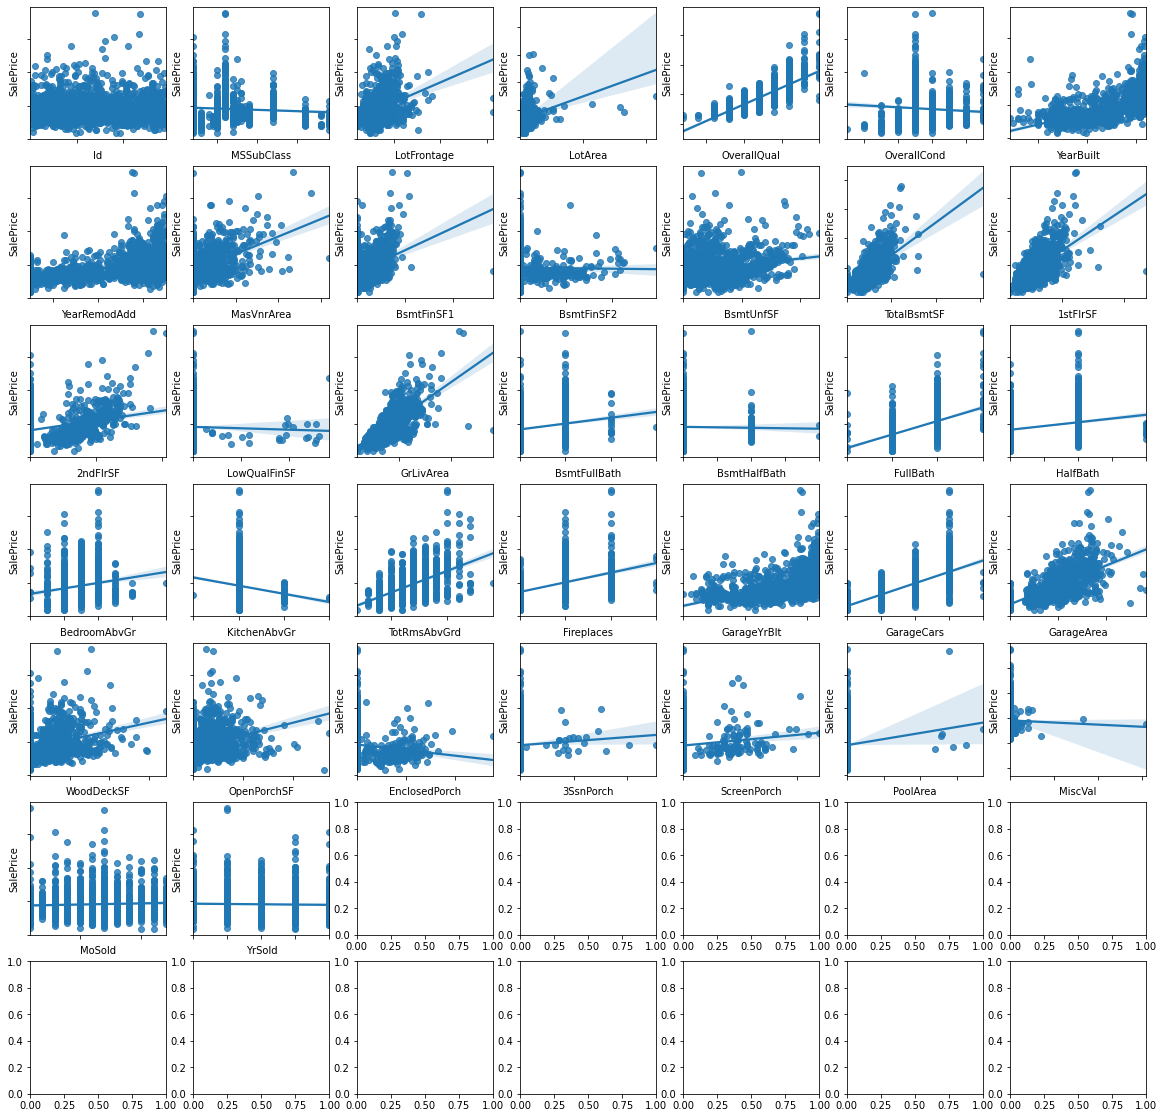

In [40]:
fig , ax = plt.subplots(7,7,figsize=(20,20))

for idx, c in enumerate(number):
    if c == "SalePrice":
        continue
    
    fig = sns.regplot(x=c, y="SalePrice", data = train, ax=ax[idx//7, idx%7])
    fig.set(yticklabels=[])
    fig.set(xticklabels=[])
    
    

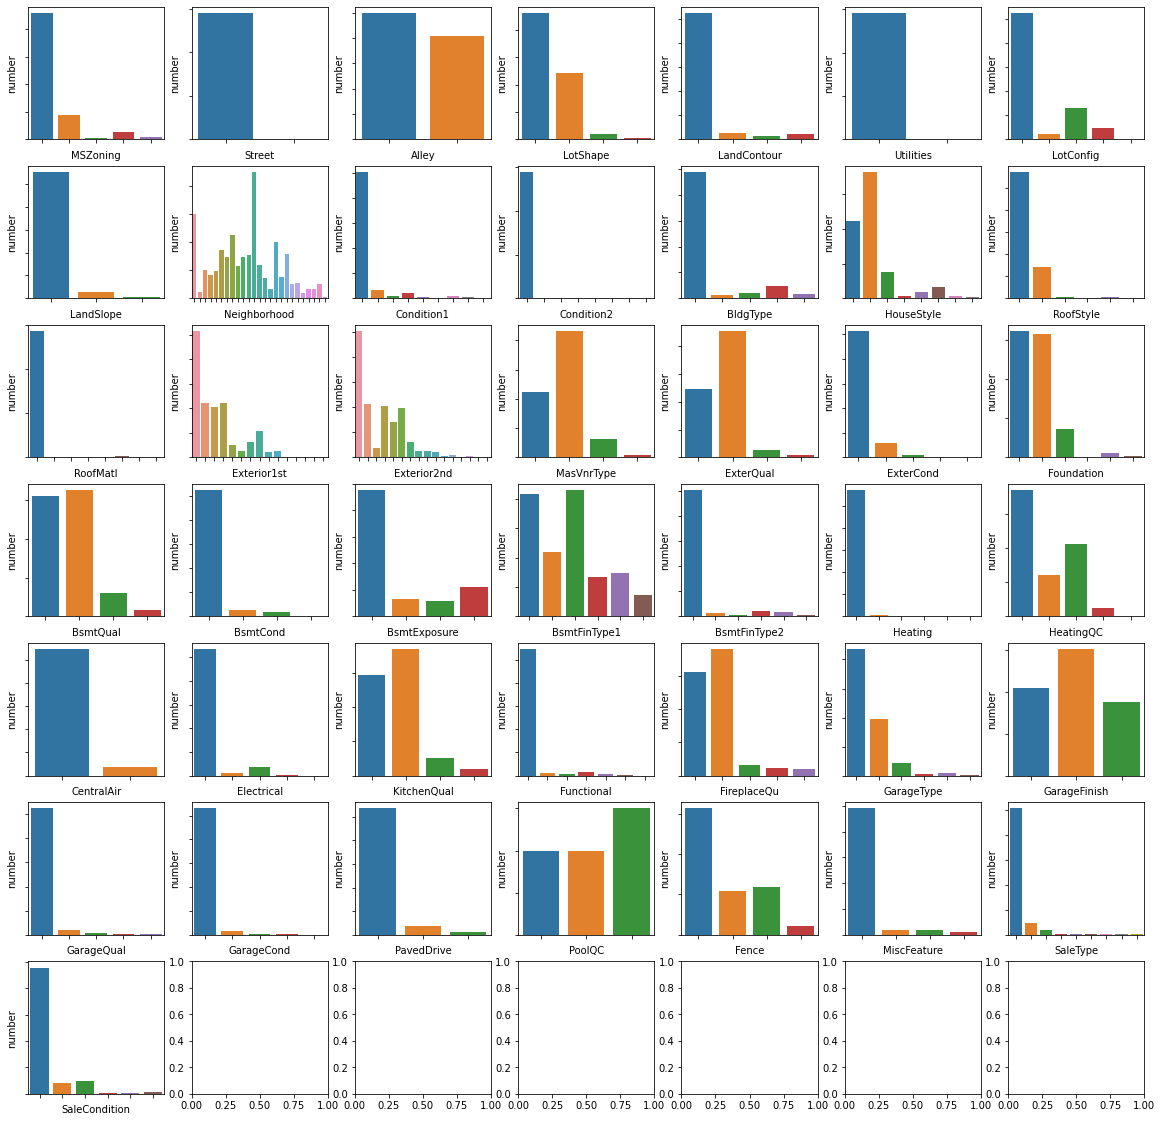

In [48]:
fig, ax = plt.subplots(7,7,figsize=(20,20))

for idx, c in enumerate(category):
    if c == 'SalePrice':
        continue
    
    fig = sns.countplot(x=c, data=train, ax = ax[idx//7, idx%7])
    fig.set(xticklabels=[])
    fig.set(yticklabels=[])
    fig.set(ylabel="number")
plt.show()

In [68]:
number

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [54]:
train["OverallQual"]

0       7
1       6
2       7
3       7
4       8
       ..
1455    6
1456    6
1457    7
1458    5
1459    5
Name: OverallQual, Length: 1460, dtype: int64

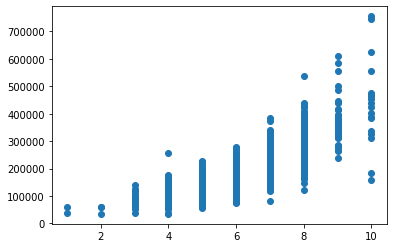

In [59]:
var = "OverallQual"
data = pd.concat([train[var], train['SalePrice']], axis=1)
plt.scatter(x=data[var], y=data["SalePrice"] )
plt.show()

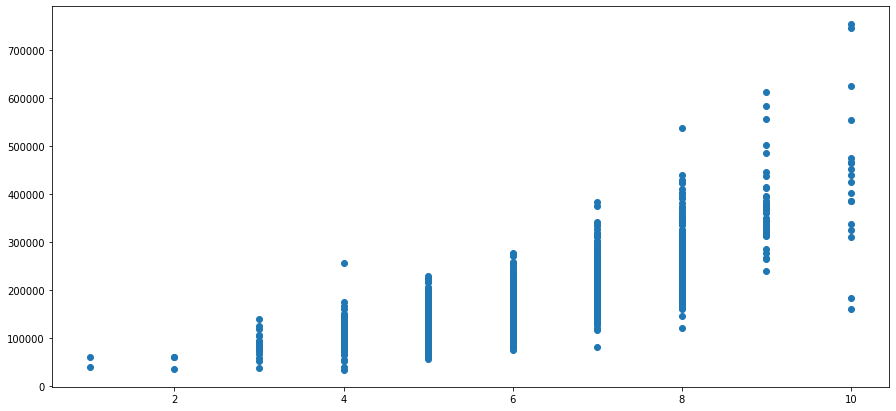

In [66]:
var ="OverallQual"
data =pd.concat([train[var], train["SalePrice"]], axis=1)
plt.subplots(figsize=(15,7))

plt.scatter(x=var, y="SalePrice", data=data)
plt.show()

[Text(0, 0.5, 'number')]

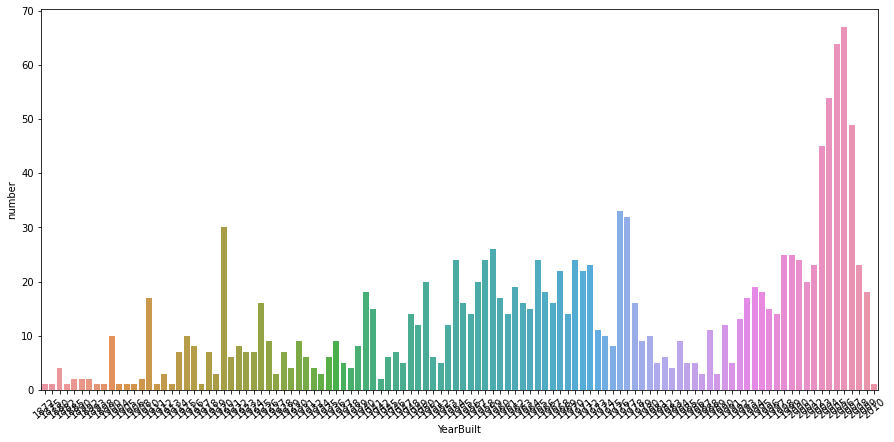

In [78]:
var = "YearBuilt"
data =pd.concat([train[var], train["SalePrice"]], axis=1)
plt.subplots(figsize=(15,7))
fig = sns.countplot(x=var, data=data)
# fig.set(xticklabels=[])
# fig.set(yticklabels=[])
plt.xticks(rotation= 40)
fig.set(ylabel="number")

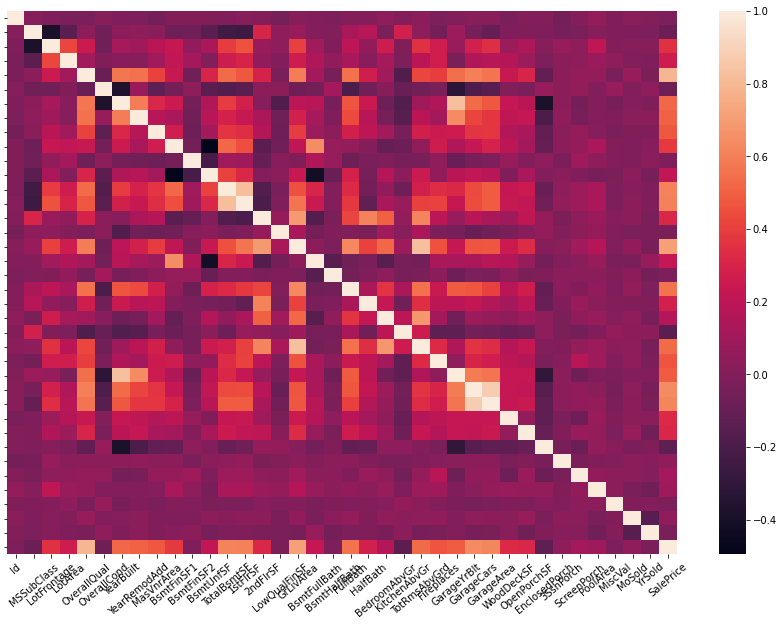

In [93]:
corr_map = train.corr()

plt.subplots(figsize=(15,10))
fig = sns.heatmap(corr_map, vmax=1 )
fig.set(yticklabels=[]);
plt.xticks(rotation=40);

In [99]:
k = 10
col = corr_map.nlargest(k, 'SalePrice')['SalePrice'].index

In [100]:
np.corrcoef(train[col])

array([[1.        , 0.99999109, 0.99999977, ..., 0.99999563, 0.99998184,
        0.99997914],
       [0.99999109, 1.        , 0.99999081, ..., 0.99998658, 0.99999536,
        0.9999949 ],
       [0.99999977, 0.99999081, 1.        , ..., 0.99999652, 0.99997963,
        0.99997728],
       ...,
       [0.99999563, 0.99998658, 0.99999652, ..., 1.        , 0.99997374,
        0.99997384],
       [0.99998184, 0.99999536, 0.99997963, ..., 0.99997374, 1.        ,
        0.99999885],
       [0.99997914, 0.9999949 , 0.99997728, ..., 0.99997384, 0.99999885,
        1.        ]])

In [102]:
np.corrcoef(train[col].values).T

array([[1.        , 0.99999109, 0.99999977, ..., 0.99999563, 0.99998184,
        0.99997914],
       [0.99999109, 1.        , 0.99999081, ..., 0.99998658, 0.99999536,
        0.9999949 ],
       [0.99999977, 0.99999081, 1.        , ..., 0.99999652, 0.99997963,
        0.99997728],
       ...,
       [0.99999563, 0.99998658, 0.99999652, ..., 1.        , 0.99997374,
        0.99997384],
       [0.99998184, 0.99999536, 0.99997963, ..., 0.99997374, 1.        ,
        0.99999885],
       [0.99997914, 0.9999949 , 0.99997728, ..., 0.99997384, 0.99999885,
        1.        ]])

In [ ]:
cm = np.corrcoef(train[col].values).T
# plt.subplots(figsize=(15,10))
sns.heatmap(cm)

In [107]:
cm = np.corrcoef(train[col].values.T)

<AxesSubplot:>

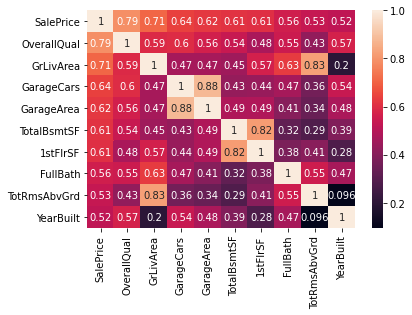

In [110]:
sns.heatmap(cm, annot=True, xticklabels=col, yticklabels=col)
